In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [7]:
filename = '/home/lacrio/DATA/term_cal/res_new_700/era5_t_uvw_20200205_20200215_thermo_budget.nc'
ds = xr.open_dataset(filename).resample(valid_time='1d').mean('valid_time') 
ds[['dT_dt', 'adv_h', 'adv_x', 'adv_y', 'adv_v', 'Q']] = ds[['dT_dt', 'adv_h', 'adv_x', 'adv_y', 'adv_v', 'Q']] * 3600 * 24
ds['t700'] = (ds['t700'] - 273.15 )
ds

<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 11, latitude: 113, longitude: 181)
Coordinates:
  * latitude    (latitude) float64 904B -70.0 -69.75 -69.5 ... -42.25 -42.0
  * longitude   (longitude) float64 1kB -85.0 -84.75 -84.5 ... -40.25 -40.0
  * valid_time  (valid_time) datetime64[ns] 88B 2020-02-05 ... 2020-02-15
Data variables:
    dT_dt       (valid_time, latitude, longitude) float64 2MB -3.936 ... -1.388
    adv_h       (valid_time, latitude, longitude) float64 2MB 4.654 ... -1.691
    adv_x       (valid_time, latitude, longitude) float32 900kB -6.462 ... -3...
    adv_y       (valid_time, latitude, longitude) float64 2MB 11.12 ... 2.022
    adv_v       (valid_time, latitude, longitude) float32 900kB -11.79 ... -6...
    Q           (valid_time, latitude, longitude) float64 2MB 3.198 ... 6.936
    t700        (valid_time, latitude, longitude) float32 900kB -5.936 ... 3.057
Attributes:
    description:  Thermodynamic budget at 700 hPa (NHESS method)
    history:      Computed from ERA5 single file

In [4]:
def thermo_weighted_table(
    ds,
    lat_min=-70, lat_max=-62,
    lon_min=-76, lon_max=-55
):
    """
    Compute area-weighted thermodynamic budget over a region
    and return a pandas DataFrame.
    """

    # --------------------------------------------
    # COORDENADAS
    # --------------------------------------------
    lons = ds['longitude'].values
    lats = ds['latitude'].values
    times = ds['valid_time'].values

    lon2d, lat2d = np.meshgrid(lons, lats)

    # --------------------------------------------
    # PESOS (cos(lat))
    # --------------------------------------------
    weights = np.sqrt(np.cos(np.deg2rad(lat2d)))

    # --------------------------------------------
    # MÁSCARA ESPACIAL
    # --------------------------------------------
    mask = (
        (lat2d >= lat_min) & (lat2d <= lat_max) &
        (lon2d >= lon_min) & (lon2d <= lon_max)
    )

    weights_masked = np.where(mask, weights, 0)

    # normalización (muy importante)
    wsum = np.sum(weights_masked)

    # --------------------------------------------
    # VARIABLES
    # --------------------------------------------
    Adv  = ds['adv_h'].values
    VAdv = ds['adv_v'].values
    Res  = ds['Q'].values
    Tend = ds['dT_dt'].values
    T    = ds['t700'].values

    # --------------------------------------------
    # PROMEDIOS ESPACIALES
    # --------------------------------------------
    def wmean(var):
        return np.sum(var * weights_masked, axis=(1,2)) / wsum

    Adv_m  = wmean(Adv)
    VAdv_m = wmean(VAdv)
    Res_m  = wmean(Res)
    Tend_m = wmean(Tend)
    T_m    = wmean(T)

    # --------------------------------------------
    # DATAFRAME (TABLA)
    # --------------------------------------------
    df = pd.DataFrame({
        "time": times,
        "tendency": Tend_m,
        "adv_h": Adv_m,
        "adv_v": VAdv_m,
        "residual": Res_m,
        "t700": T_m
    })

    df = df.set_index("time")

    return df


In [8]:
df_PIs = thermo_weighted_table(ds, lat_min=-52.5, lat_max=-45, lon_min=-74.5, lon_max=-72)
df_APIS = thermo_weighted_table(ds, lat_min=-70, lat_max=-62, lon_min=-76, lon_max=-55)

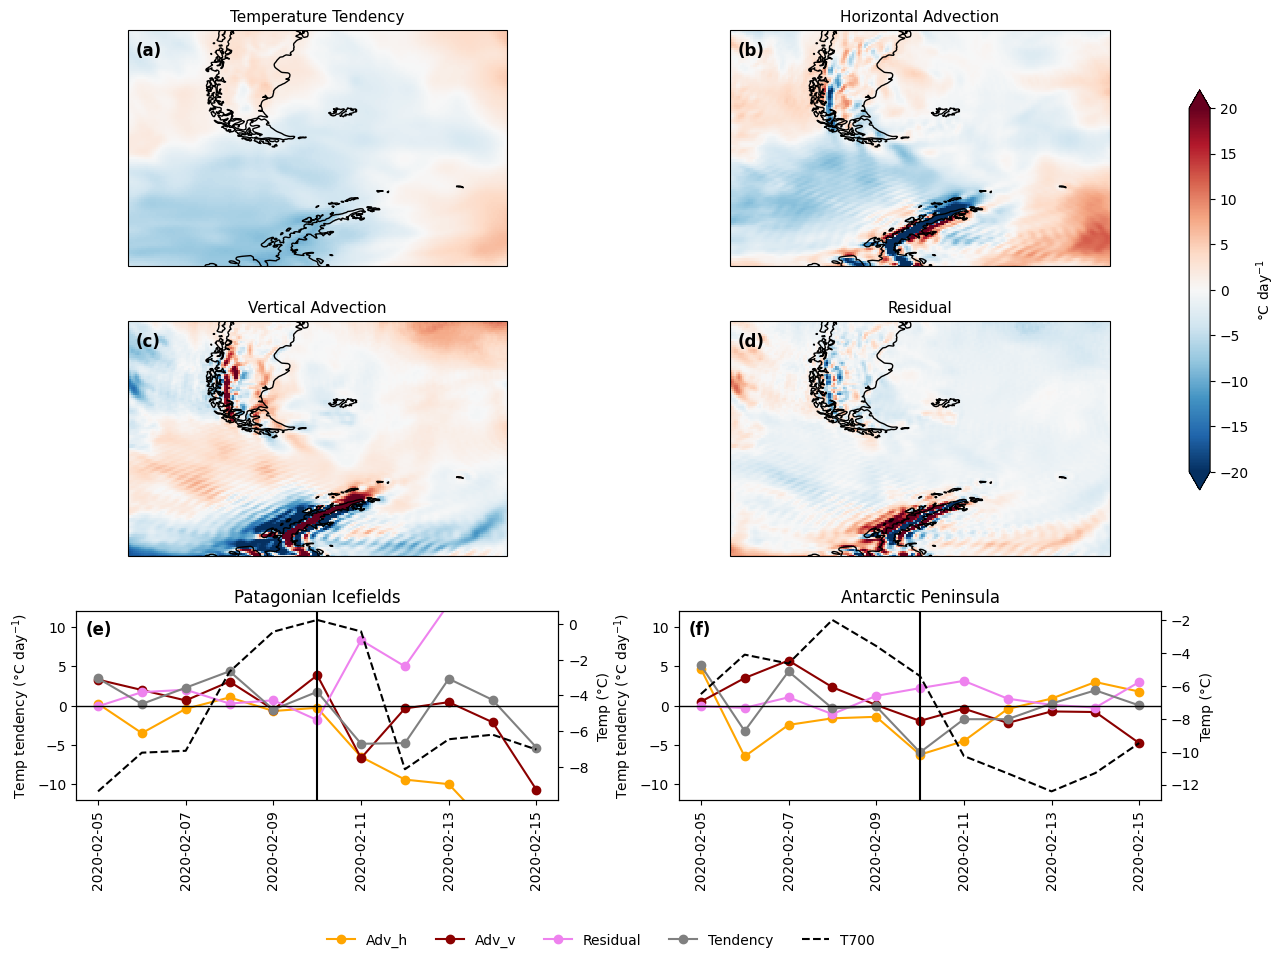

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# ============================================
# SELECT TIME
# ============================================
time_sel = '2020-02-10'
ds_sel = ds.sel(valid_time=time_sel)

event_date = np.datetime64("2020-02-10")

# ============================================
# FIGURE + GRID (BALANCED)
# ============================================
fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 0.8],   # 🔥 mejor proporción
    hspace=0.25,
    wspace=0.25
)

plt.subplots_adjust(right=0.9)  # espacio para colorbar

# ============================================
# MAPS (a–d)
# ============================================
axes_map = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree()),
]

vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    "Temperature Tendency",
    "Horizontal Advection",
    "Vertical Advection",
    "Residual"
]

lon = ds_sel.longitude
lat = ds_sel.latitude

vmax = 20
vmin = -vmax

for i, ax in enumerate(axes_map):

    im = ax.pcolormesh(
        lon,
        lat,
        ds_sel[vars_plot[i]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m")

    ax.set_extent([
        float(lon.min()), float(lon.max()),
        float(lat.min())+1.5, float(lat.max())
    ])

    ax.set_title(titles[i], fontsize=11)

    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

# ============================================
# COLORBAR (INDEPENDENT)
# ============================================
cax = fig.add_axes([0.92, 0.42, 0.015, 0.4])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='both'
)

cbar.set_label("°C day$^{-1}$")

# ============================================
# TIME SERIES (e–f)
# ============================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[2, 0])
ax1b = ax1.twinx()

t = df_PIs.index

l1, = ax1.plot(t, df_PIs["adv_h"], 'o-', color='orange')
l2, = ax1.plot(t, df_PIs["adv_v"], 'o-', color='darkred')
l3, = ax1.plot(t, df_PIs["residual"], 'o-', color='violet')
l4, = ax1.plot(t, df_PIs["tendency"], 'o-', color='gray')
l5, = ax1b.plot(t, df_PIs["t700"], '--', color='k')

ax1.axhline(0, color='k', linewidth=1)
ax1.axvline(event_date, color='k', linestyle='-')

ax1.set_ylim(-12, 12)
ax1.set_title("Patagonian Icefields")

ax1.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax1b.set_ylabel('Temp (°C)')

# mover eje derecho
ax1b.yaxis.set_label_coords(1.08, 0.5)

ax1.text(0.02, 0.95, "(e)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="top")


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[2, 1])
ax2b = ax2.twinx()

t = df_APIS.index

ax2.plot(t, df_APIS["adv_h"], 'o-', color='orange')
ax2.plot(t, df_APIS["adv_v"], 'o-', color='darkred')
ax2.plot(t, df_APIS["residual"], 'o-', color='violet')
ax2.plot(t, df_APIS["tendency"], 'o-', color='gray')
ax2b.plot(t, df_APIS["t700"], '--', color='k')

ax2.axhline(0, color='k', linewidth=1)
ax2.axvline(event_date, color='k', linestyle='-')

ax2.set_ylim(-12, 12)
ax2.set_title("Antarctic Peninsula")

# evitar duplicación
ax2.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax2b.set_ylabel('Temp (°C)')
ax2b.yaxis.set_label_coords(1.08, 0.5)

ax2.text(0.02, 0.95, "(f)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="top")

# ============================================
# LEGEND (SOLO TIME SERIES, CENTRADA)
# ============================================
fig.legend(
    [l1, l2, l3, l4, l5],
    ['Adv_h', 'Adv_v', 'Residual', 'Tendency', 'T700'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=False,
    fontsize=10
)

# ============================================
# FORMAT
# ============================================
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=90)

#fig.savefig(
#    "./fig/temp_tendency_sergi_2020.png",
#    dpi=300,
#    bbox_inches="tight"
#)


In [13]:
base_dir    = "/home/lacrio/DATA/term_cal/res_new_700"
csv_days    = "/home/lacrio/DATA/term_cal/range_date_evets.csv"
nc_pattern  = "era5_t_uvw_{start}_{end}_thermo_budget.nc"


In [23]:
def load_event(row, i):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])
    central = pd.to_datetime(row["event_date"])

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )
    ds = xr.open_dataset(path).resample(valid_time='1d').mean('valid_time').sel(valid_time=central)
    ds[['dT_dt', 'adv_h', 'adv_x', 'adv_y', 'adv_v', 'Q']] = ds[['dT_dt', 'adv_h', 'adv_x', 'adv_y', 'adv_v', 'Q']] * 3600 * 24
    ds['t700'] = (ds['t700'] - 273.15 )

    return ds

def load_ds(row, i):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )
    ds = xr.open_dataset(path).resample(valid_time='1d').mean('valid_time') 
    ds[['dT_dt', 'adv_h', 'adv_x', 'adv_y', 'adv_v', 'Q']] = ds[['dT_dt', 'adv_h', 'adv_x', 'adv_y', 'adv_v', 'Q']] * 3600 * 24
    ds['t700'] = (ds['t700'] - 273.15 )
    
    return ds


In [15]:
df = pd.read_csv(csv_days)#[0:20]
df

,start_date,event_date,end_date
0,1980-02-12,1980-02-17,1980-02-22
1,1980-12-18,1980-12-23,1980-12-28
2,1981-01-21,1981-01-26,1981-01-31
3,1981-12-04,1981-12-09,1981-12-14
4,1982-02-25,1982-03-02,1982-03-07
...,...,...,...
95,2021-11-04,2021-11-09,2021-11-14
96,2021-12-03,2021-12-08,2021-12-13
97,2021-12-14,2021-12-19,2021-12-24
98,2022-02-02,2022-02-07,2022-02-12


In [18]:
datasets_event = []

for i, row in df.iterrows():

    ds_evt = load_event(row, i)

    datasets_event.append(ds_evt)


In [19]:
def make_relative_time(df_event, event_date):
    """
    Convierte el índice temporal a días relativos al evento
    """
    df_rel = df_event.copy()

    # asegurar datetime
    df_rel.index = np.array(df_rel.index, dtype='datetime64[ns]')
    event_date = np.datetime64(event_date)

    # tiempo relativo en días
    rel_time = (df_rel.index - event_date) / np.timedelta64(1, 'D')

    df_rel.index = rel_time.astype(int)

    return df_rel

In [24]:
df_PIs_list = []
df_APIS_list = []

for i, row in df.iterrows():

    ds_ev = load_ds(row, i)

    df_PIs = thermo_weighted_table(
        ds_ev,
        lat_min=-52.5, lat_max=-45,
        lon_min=-74.5, lon_max=-72
    )

    df_APIS = thermo_weighted_table(
        ds_ev,
        lat_min=-70, lat_max=-62,
        lon_min=-76, lon_max=-55
    )

    # 🔥 convertir a tiempo relativo
    df_PIs = make_relative_time(df_PIs, row["event_date"])
    df_APIS = make_relative_time(df_APIS, row["event_date"])

    df_PIs_list.append(df_PIs)
    df_APIS_list.append(df_APIS)

In [25]:
df_PIs_comp = pd.concat(df_PIs_list).groupby(level=0).mean()
df_APIS_comp = pd.concat(df_APIS_list).groupby(level=0).mean()
ds_comp = xr.concat(datasets_event, dim='time').mean('time')

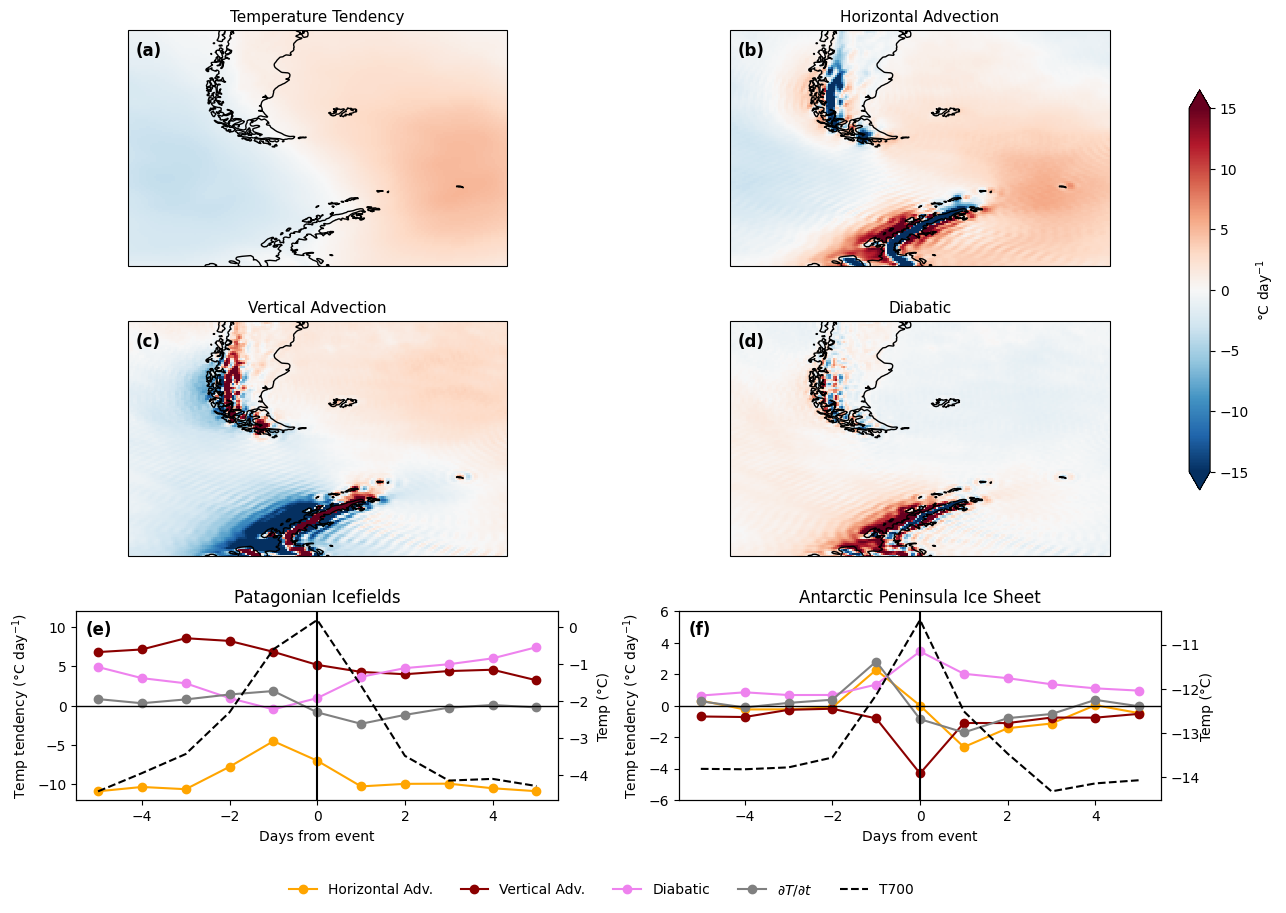

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# ============================================
# SELECT COMPOSITE TIME (0 = EVENT DAY)
# ============================================
time_sel = 0   # 🔥 clave: tiempo relativo
ds_sel = ds_comp#.sel(time=time_sel)

# ============================================
# FIGURE + GRID
# ============================================
fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 0.8],
    hspace=0.25,
    wspace=0.25
)

plt.subplots_adjust(right=0.9)

# ============================================
# MAPS (a–d)
# ============================================
axes_map = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree()),
]

vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    "Temperature Tendency",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic"
]

lon = ds_sel.longitude
lat = ds_sel.latitude

vmax = 15
vmin = -vmax

for i, ax in enumerate(axes_map):

    im = ax.pcolormesh(
        lon,
        lat,
        ds_sel[vars_plot[i]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m")

    ax.set_extent([
        float(lon.min()), float(lon.max()),
        float(lat.min())+1.5, float(lat.max())
    ])

    ax.set_title(titles[i], fontsize=11)

    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

# ============================================
# COLORBAR
# ============================================
cax = fig.add_axes([0.92, 0.42, 0.015, 0.4])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='both'
)

cbar.set_label("°C day$^{-1}$")

# ============================================
# TIME SERIES (RELATIVE TIME)
# ============================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[2, 0])
ax1b = ax1.twinx()

t = df_PIs_comp.index  # 🔥 tiempo relativo

l1, = ax1.plot(t, df_PIs_comp["adv_h"], 'o-', color='orange')
l2, = ax1.plot(t, df_PIs_comp["adv_v"], 'o-', color='darkred')
l3, = ax1.plot(t, df_PIs_comp["residual"], 'o-', color='violet')
l4, = ax1.plot(t, df_PIs_comp["tendency"], 'o-', color='gray')
l5, = ax1b.plot(t, df_PIs_comp["t700"], '--', color='k')

# 🔥 EVENT DAY = 0
ax1.axvline(0, color='k', linestyle='-')
ax1.axhline(0, color='k', linewidth=1)

ax1.set_ylim(-12, 12)
ax1.set_title("Patagonian Icefields")

ax1.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax1b.set_ylabel('Temp (°C)')
ax1b.yaxis.set_label_coords(1.08, 0.5)

ax1.text(0.02, 0.95, "(e)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="top")


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[2, 1])
ax2b = ax2.twinx()

t = df_APIS_comp.index

ax2.plot(t, df_APIS_comp["adv_h"], 'o-', color='orange')
ax2.plot(t, df_APIS_comp["adv_v"], 'o-', color='darkred')
ax2.plot(t, df_APIS_comp["residual"], 'o-', color='violet')
ax2.plot(t, df_APIS_comp["tendency"], 'o-', color='gray')
ax2b.plot(t, df_APIS_comp["t700"], '--', color='k')

ax2.axvline(0, color='k', linestyle='-')
ax2.axhline(0, color='k', linewidth=1)

ax2.set_ylim(-6, 6)
ax2.set_title("Antarctic Peninsula Ice Sheet")

ax2.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax2b.set_ylabel('Temp (°C)')
ax2b.yaxis.set_label_coords(1.08, 0.5)

ax2.text(0.02, 0.95, "(f)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="top")

# ============================================
# LEGEND
# ============================================
fig.legend(
    [l1, l2, l3, l4, l5],
    ["Horizontal Adv.", "Vertical Adv.", "Diabatic", r"$\partial T / \partial t$", "T700"],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.0),
    ncol=5,
    frameon=False,
    fontsize=10
)

# ============================================
# FORMAT
# ============================================
for ax in [ax1, ax2]:
    ax.set_xlabel("Days from event")
    ax.tick_params(axis='x', rotation=0)

# ============================================
# SAVE
# ============================================
#fig.savefig(
#    "./fig/temp_tendency_composite.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

In [29]:
df_PIs_comp.round(2)

,tendency,adv_h,adv_v,residual,t700
-5,0.83,-10.90,6.82,4.92,-4.44
-4,0.31,-10.35,7.15,3.50,-3.95
-3,0.79,-10.63,8.58,2.84,-3.44
-2,1.42,-7.78,8.24,0.96,-2.31
-1,1.86,-4.52,6.85,-0.47,-0.61
0,-0.85,-7.01,5.19,0.96,0.18
1,-2.31,-10.28,4.30,3.67,-1.59
2,-1.17,-9.95,4.00,4.78,-3.48
3,-0.26,-9.93,4.40,5.27,-4.15
4,0.08,-10.51,4.57,6.02,-4.11


In [30]:
df_APIS_comp.round(2)

,tendency,adv_h,adv_v,residual,t700
-5,0.28,0.32,-0.69,0.64,-13.81
-4,-0.11,-0.24,-0.72,0.85,-13.82
-3,0.18,-0.23,-0.27,0.68,-13.78
-2,0.38,-0.11,-0.19,0.68,-13.55
-1,2.81,2.28,-0.81,1.34,-12.14
0,-0.86,0.00,-4.31,3.45,-10.44
1,-1.71,-2.63,-1.10,2.03,-12.51
2,-0.79,-1.43,-1.11,1.75,-13.47
3,-0.53,-1.14,-0.76,1.36,-14.32
4,0.37,0.03,-0.76,1.10,-14.14
